In [1]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
import numpy as np
import os
import cv2

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
        

In [2]:
# Corrected directory path
dir_name = r"D:\python\dataset\faces"

y = []
X = []
target_names = []
class_names = []
person_id = 0
h = w = 300
n_samples = 0

# Iterate through each person in the directory
for person_name in os.listdir(dir_name):
    print(person_name)

    # Corrected path joining
    dir_path = os.path.join(dir_name, person_name)
    
    # Ensure it's a directory
    if not os.path.isdir(dir_path):
        continue

    class_names.append(person_name)

    for image_name in os.listdir(dir_path):
        # Formulate the correct image path
        image_path = os.path.join(dir_path, image_name)

        # Read the input image
        img = cv2.imread(image_path)
        if img is None:
            print(f"Warning: Cannot read image {image_path}")
            continue

        # Convert into grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize image to 300x300 dimensions
        resized_image = cv2.resize(gray, (h, w))

        # Convert matrix to vector
        v = resized_image.flatten()
        X.append(v)

        # Increase the number of samples
        n_samples += 1

        # Add categorical label
        y.append(person_id)

        # Adding the person name
        target_names.append(person_name)

    # Increase the person ID by 1
    person_id += 1

# Transform lists to NumPy arrays
y = np.array(y)
X = np.array(X)
target_names = np.array(class_names)  # Assign class_names correctly

# Ensure shapes are correct before accessing
if X.size > 0:
    n_features = X.shape[1]
else:
    n_features = 0

print(y.shape, X.shape, target_names.shape)
print("Number of samples:", n_samples)

# Compute number of classes
n_classes = len(class_names)

print("Total dataset size:")
print(f"n_samples: {n_samples}")
print(f"n_features: {n_features}")
print(f"n_classes: {n_classes}")

Aamir
Ajay
Akshay
Alia
Amitabh
Deepika
Disha
Farhan
Ileana
(450,) (450, 90000) (9,)
Number of samples: 450
Total dataset size:
n_samples: 450
n_features: 90000
n_classes: 9


Extracting the top 150 eigenfaces from 337 faces


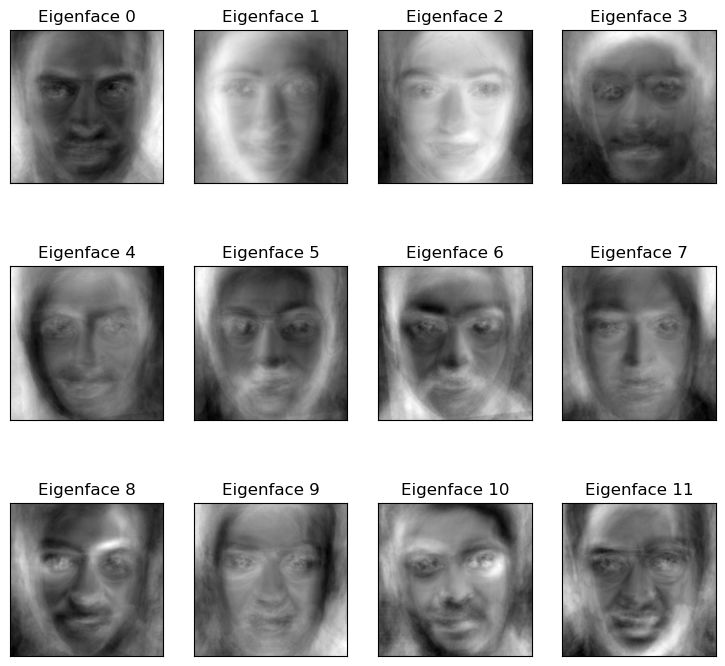

Projecting the input data onto the eigenfaces orthonormal basis
Train PCA shape: (337, 150), Test PCA shape: (113, 150)
Projection completed successfully.


In [3]:

# Split into a training set and a test set using a stratified k-fold
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

###############################################################################
# Compute PCA (Eigenfaces) for dimensionality reduction
n_components = 150

print(f"Extracting the top {n_components} eigenfaces from {X_train.shape[0]} faces")

# Ensure we have enough samples for PCA
assert X_train.shape[0] >= n_components, "Not enough samples for PCA"

# Applying PCA
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_train)

# Generating eigenfaces
eigenfaces = pca.components_.reshape((n_components, h, w))

# Plot eigenfaces
eigenface_titles = [f"Eigenface {i}" for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)

plt.show()

print("Projecting the input data onto the eigenfaces orthonormal basis")
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Train PCA shape: {X_train_pca.shape}, Test PCA shape: {X_test_pca.shape}")

###############################################################################
# Compute Fisherfaces (LDA on PCA-reduced data)
lda = LinearDiscriminantAnalysis()

# Fit and transform LDA
lda.fit(X_train_pca, y_train)
X_train_lda = lda.transform(X_train_pca)
X_test_lda = lda.transform(X_test_pca)

print("Projection completed successfully.")

In [4]:

# Training with Multi-Layer Perceptron
clf = MLPClassifier(random_state=42, hidden_layer_sizes=(15, 10), max_iter=1200, verbose=True).fit(X_train_lda, y_train)

print("Updated Model Weights:")
model_info = [coef.shape for coef in clf.coefs_]
print(model_info)

Iteration 1, loss = 3.43506021
Iteration 2, loss = 3.35409730
Iteration 3, loss = 3.27693133
Iteration 4, loss = 3.20061323
Iteration 5, loss = 3.12778303
Iteration 6, loss = 3.06265786
Iteration 7, loss = 2.99751606
Iteration 8, loss = 2.93659081
Iteration 9, loss = 2.87847859
Iteration 10, loss = 2.82427318
Iteration 11, loss = 2.77025968
Iteration 12, loss = 2.71980506
Iteration 13, loss = 2.67414887
Iteration 14, loss = 2.62744995
Iteration 15, loss = 2.58568724
Iteration 16, loss = 2.54344075
Iteration 17, loss = 2.50479621
Iteration 18, loss = 2.46706603
Iteration 19, loss = 2.43163564
Iteration 20, loss = 2.39638339
Iteration 21, loss = 2.36266800
Iteration 22, loss = 2.32923231
Iteration 23, loss = 2.29798836
Iteration 24, loss = 2.26733331
Iteration 25, loss = 2.23752674
Iteration 26, loss = 2.20791217
Iteration 27, loss = 2.17917967
Iteration 28, loss = 2.15215305
Iteration 29, loss = 2.12484813
Iteration 30, loss = 2.09843227
Iteration 31, loss = 2.07228991
Iteration 32, los

Accuracy: 70.79646017699115


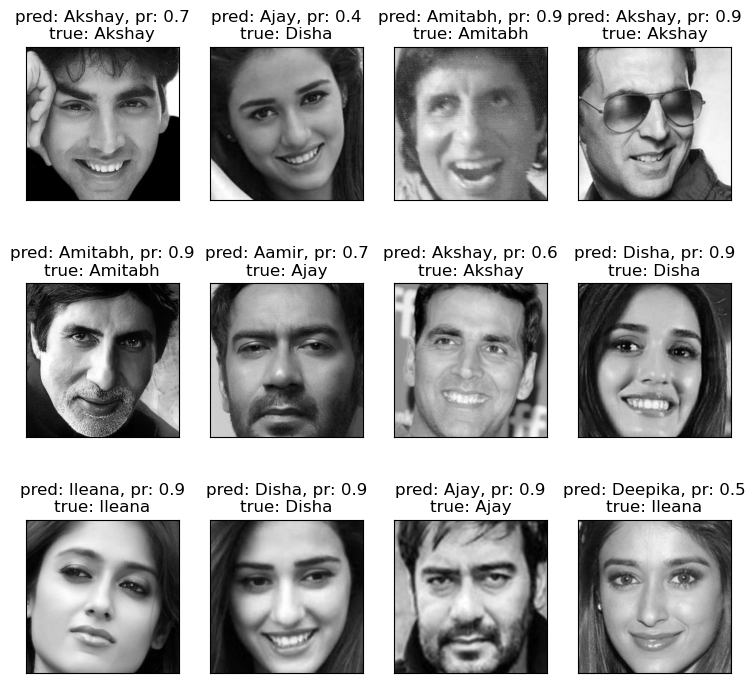

In [5]:
y_pred = [];y_prob = []
for test_face in X_test_lda:
    prob = clf.predict_proba([test_face])[0]
    # print(prob,np.max(prob))
    class_id = np.where(prob == np.max(prob))[0][0]
    # print(class_index)
    # Find the label of the matched face
    y_pred.append(class_id)
    y_prob.append(np.max(prob))

# Transform the data
y_pred = np.array(y_pred)

prediction_titles = []
true_positive = 0
for i in range(y_pred.shape[0]):
    # print(y_test[i],y_pred[i])
    # true_name = target_names[y_test[i]].rsplit(' ', 1)[-1]
    # pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]
    true_name = class_names[y_test[i]]
    pred_name = class_names[y_pred[i]]
    result = 'pred: %s, pr: %s\ntrue: %s' % (pred_name, str(y_prob[i])[0:3], true_name)
    # result = 'prediction: %s\ntrue: %s' % (pred_name, true_name)
    prediction_titles.append(result)
    if true_name == pred_name:
        true_positive = true_positive+1

print("Accuracy:",true_positive*100/y_pred.shape[0])

# # Plot results
plot_gallery(X_test, prediction_titles, h, w)
plt.show()